<a href="https://colab.research.google.com/github/Prudhvilakshman1112/GEN-AI/blob/main/Project_Gen_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project Overview: The Fashion Morpher
Goal: Learn the "DNA" of clothing items and generate hybrid designs.

Tech Used: Variational Autoencoder (VAE), Reparameterization Trick, Latent Space Interpolation.

Dataset: Fashion-MNIST (10 classes of clothing).

Why this? It's computationally light for Colab but more "creative" than digit generation.

#Cell 1: Setup and Dataset
We load the Fashion-MNIST dataset. This is the "modern" version of MNIST, containing $28 \times 28$ grayscale images of 10 types of clothing.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Labels for reference
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
print(f"Dataset loaded. Using device: {device}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.4MB/s]

Dataset loaded. Using device: cuda


#Cell 2: The VAE Architecture
This model utilizes an Encoder to find the "mean" and "variance" of a style and a Decoder to turn those styles back into images. The Reparameterization Trick is used here to allow the gradients to flow through the random sampling process.

In [2]:
class FashionVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(FashionVAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

model = FashionVAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

#Cell 3: Training the Designer
The loss function here is a balance: Reconstruction Loss (does it look like a shirt?) and KL Divergence (is the style space organized?). We only train for 10-15 epochs to keep it fast for Colab.

In [3]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

epochs = 15
model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch+1}, Avg Loss: {train_loss / len(train_loader.dataset):.4f}')

Epoch 1, Avg Loss: 285.2590
Epoch 2, Avg Loss: 256.2596
Epoch 3, Avg Loss: 250.7083
Epoch 4, Avg Loss: 247.8933
Epoch 5, Avg Loss: 246.2312
Epoch 6, Avg Loss: 245.1287
Epoch 7, Avg Loss: 244.3495
Epoch 8, Avg Loss: 243.7605
Epoch 9, Avg Loss: 243.2699
Epoch 10, Avg Loss: 242.8021
Epoch 11, Avg Loss: 242.4895
Epoch 12, Avg Loss: 242.1643
Epoch 13, Avg Loss: 241.8831
Epoch 14, Avg Loss: 241.6572
Epoch 15, Avg Loss: 241.4369


#Cell 4: Latent Space Morphing (The Project Output)
This is where the magic happens. We take two different items (e.g., a Boot and a Sneaker), find their "style coordinates" in the latent space, and then walk the path between them to generate hybrid designs.

Morphing from Sneaker to Ankle Boot:


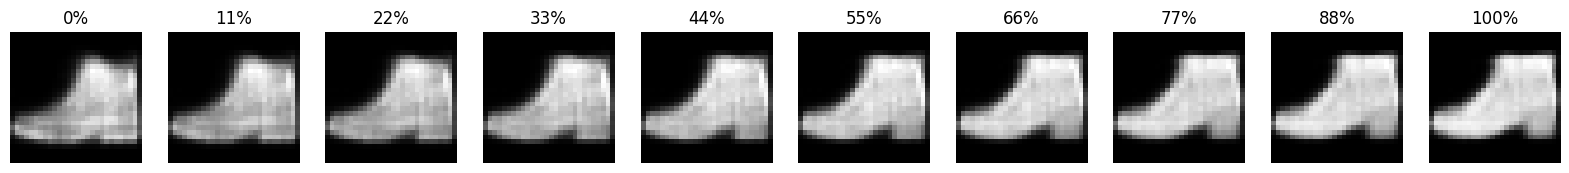

In [4]:
model.eval()
with torch.no_grad():
    # In Fashion-MNIST: Sneaker is index 7, Ankle Boot is index 9
    sneaker_idx = 7
    boot_idx = 9

    img_sneaker = None
    img_boot = None

    # Iterate through the dataloader until we find one of each
    for data, labels in train_loader:
        # Check if there is a sneaker in this batch
        if img_sneaker is None and (labels == sneaker_idx).any():
            # Get the index of the first sneaker in the batch
            idx = (labels == sneaker_idx).nonzero(as_tuple=True)[0][0]
            img_sneaker = data[idx].unsqueeze(0).to(device)

        # Check if there is an ankle boot in this batch
        if img_boot is None and (labels == boot_idx).any():
            # Get the index of the first ankle boot in the batch
            idx = (labels == boot_idx).nonzero(as_tuple=True)[0][0]
            img_boot = data[idx].unsqueeze(0).to(device)

        # Stop searching if we have found both images
        if img_sneaker is not None and img_boot is not None:
            break

    # Get their latent representations (mu)
    _, mu1, _ = model(img_sneaker)
    _, mu2, _ = model(img_boot)

    # Interpolate between the two points
    steps = 10
    fig, axs = plt.subplots(1, steps, figsize=(20, 3))
    print(f"Morphing from {classes[sneaker_idx]} to {classes[boot_idx]}:")

    for i in range(steps):
        alpha = i / (steps - 1)
        z = (1 - alpha) * mu1 + alpha * mu2
        sample = model.decoder(z).cpu().view(28, 28).numpy()

        axs[i].imshow(sample, cmap='gray')
        axs[i].axis('off')
        axs[i].set_title(f"{int(alpha*100)}%")

plt.show()